In [1]:
from itertools import cycle

import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import enet_path, lars_path, lasso_path

In [4]:

eps = 5e-3  # the smaller it is the longer is the path

print("Computing regularization path using the lasso...")
alphas_lasso, coefs_lasso, _ = lasso_path(X, y, eps=eps)

print("Computing regularization path using the positive lasso...")
alphas_positive_lasso, coefs_positive_lasso, _ = lasso_path(
    X, y, eps=eps, positive=True
)

print("Computing regularization path using the LARS...")
alphas_lars, _, coefs_lars = lars_path(X, y, method="lasso")

print("Computing regularization path using the positive LARS...")
alphas_positive_lars, _, coefs_positive_lars = lars_path(
    X, y, method="lasso", positive=True
)

print("Computing regularization path using the elastic net...")
alphas_enet, coefs_enet, _ = enet_path(X, y, eps=eps, l1_ratio=0.8)

print("Computing regularization path using the positive elastic net...")
alphas_positive_enet, coefs_positive_enet, _ = enet_path(
    X, y, eps=eps, l1_ratio=0.8, positive=True
)


Computing regularization path using the lasso...
Computing regularization path using the positive lasso...
Computing regularization path using the LARS...
Computing regularization path using the positive LARS...
Computing regularization path using the elastic net...
Computing regularization path using the positive elastic net...


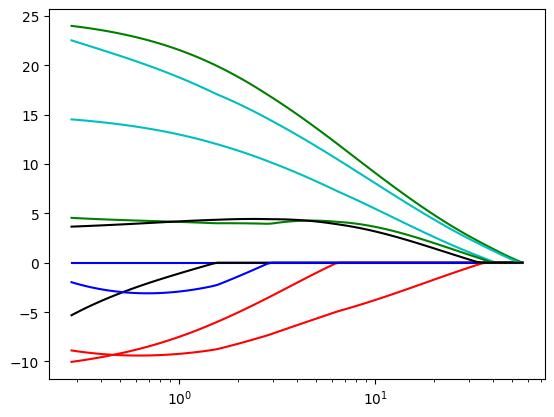

In [13]:

colors = cycle(["b", "r", "g", "c", "k"])
plt.figure()
for coef_e, coef_pe, c in zip(coefs_enet, coefs_positive_enet, colors):
    l1 = plt.semilogx(alphas_enet, coef_e, c=c)
    # l2 = plt.semilogx(alphas_positive_enet, coef_pe, linestyle="--", c=c)


plt.show()

Computing regularization path using the lasso...


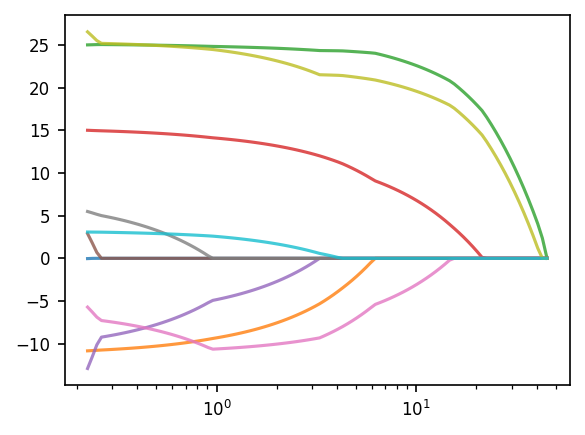

In [17]:
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path
from itertools import cycle
import numpy as np

# Generate sample data or use your X, y
# Uncomment and modify for your actual data:
# from sklearn.datasets import make_regression
# X, y = make_regression(n_samples=100, n_features=10, n_informative=5, random_state=42)

eps = 5e-3
print("Computing regularization path using the lasso...")
alphas_lasso, coefs_lasso, _ = lasso_path(X, y, eps=eps)

# Create figure with better styling for a small inset
fig, ax = plt.subplots(figsize=(4, 3), dpi=150)

# Use distinct colors
colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

# Plot coefficient paths
for coef, c in zip(coefs_lasso, colors):
    ax.semilogx(alphas_lasso, coef, c=c, linewidth=1.5, alpha=0.8)

# Remove axis labels but keep ticks for context
ax.set_xlabel('')
ax.set_ylabel('')


# Improve tick labels for small figure
ax.tick_params(labelsize=8)


# Tighten layout
plt.tight_layout()

# Add subtle axis titles as tick labels (optional)
# ax.text(0.5, -0.15, 'α (regularization)', transform=ax.transAxes, 
#         ha='center', fontsize=8, style='italic')
# ax.text(-0.15, 0.5, 'Coefficients', transform=ax.transAxes, 
#         ha='center', va='center', rotation=90, fontsize=8, style='italic')

# plt.show()
plt.savefig('/Volumes/rsrch5/home/trans_mol_path/cercan/BE_master/4.plotting/output/0.input/lasso_path.svg', format='svg', bbox_inches='tight')
# For saving as part of larger figure:
# plt.savefig('lasso_path.pdf', bbox_inches='tight', dpi=300)